# Spark Connect Demo

Connects to the Spark Connect Server running in the `spark` namespace and demonstrates:
- Remote SparkSession via Spark Connect
- Apache Iceberg table creation on MinIO (S3A)
- DataFrame operations and queries

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, avg, current_timestamp
import pandas as pd

# Requires: kubectl port-forward svc/spark-connect-server 15002:15002 -n spark
spark = (
    SparkSession.builder
    .remote("sc://localhost:15002")
    .appName("jupyter-demo")
    .getOrCreate()
)

print(f"Spark version: {spark.version}")
print("Connected to Spark Connect Server")

Spark version: 3.5.3
Connected to Spark Connect Server


## 1. Basic DataFrame Operations

In [2]:
# Create a sample DataFrame
data = [
    ("Alice", "engineering", 95000),
    ("Bob", "marketing", 72000),
    ("Carol", "engineering", 105000),
    ("Dave", "marketing", 68000),
    ("Eve", "engineering", 98000),
    ("Frank", "sales", 82000),
]
columns = ["name", "department", "salary"]

df = spark.createDataFrame(data, columns)
df.show()

+-----+-----------+------+
| name| department|salary|
+-----+-----------+------+
|Alice|engineering| 95000|
|  Bob|  marketing| 72000|
|Carol|engineering|105000|
| Dave|  marketing| 68000|
|  Eve|engineering| 98000|
|Frank|      sales| 82000|
+-----+-----------+------+



In [3]:
# Aggregations
dept_stats = (
    df.groupBy("department")
    .agg(
        count("*").alias("headcount"),
        avg("salary").alias("avg_salary"),
    )
    .orderBy("department")
)
dept_stats.show()

+-----------+---------+-----------------+
| department|headcount|       avg_salary|
+-----------+---------+-----------------+
|engineering|        3|99333.33333333333|
|  marketing|        2|          70000.0|
|      sales|        1|          82000.0|
+-----------+---------+-----------------+



## 2. SQL Queries

In [4]:
df.createOrReplaceTempView("employees")

result = spark.sql("""
    SELECT department, name, salary,
           RANK() OVER (PARTITION BY department ORDER BY salary DESC) AS rank
    FROM employees
""")
result.show()

+-----------+-----+------+----+
| department| name|salary|rank|
+-----------+-----+------+----+
|engineering|Carol|105000|   1|
|engineering|  Eve| 98000|   2|
|engineering|Alice| 95000|   3|
|  marketing|  Bob| 72000|   1|
|  marketing| Dave| 68000|   2|
|      sales|Frank| 82000|   1|
+-----------+-----+------+----+



## 3. Iceberg Table via MinIO

In [5]:
# Write to Iceberg table in MinIO warehouse
(
    df.withColumn("ingested_at", current_timestamp())
    .writeTo("local.jupyter.employees")
    .using("iceberg")
    .createOrReplace()
)

print("Written to Iceberg table: local.jupyter.employees")

Written to Iceberg table: local.jupyter.employees


In [6]:
# Read back from Iceberg
iceberg_df = spark.table("local.jupyter.employees")
iceberg_df.show()
print(f"Row count: {iceberg_df.count()}")

+-----+-----------+------+--------------------+
| name| department|salary|         ingested_at|
+-----+-----------+------+--------------------+
|Alice|engineering| 95000|2026-03-16 02:59:...|
|  Bob|  marketing| 72000|2026-03-16 02:59:...|
|Carol|engineering|105000|2026-03-16 02:59:...|
| Dave|  marketing| 68000|2026-03-16 02:59:...|
|  Eve|engineering| 98000|2026-03-16 02:59:...|
|Frank|      sales| 82000|2026-03-16 02:59:...|
+-----+-----------+------+--------------------+

Row count: 6


In [7]:
# Iceberg table history
spark.sql("SELECT * FROM local.jupyter.employees.history").show(truncate=False)

+-----------------------+-------------------+---------+-------------------+
|made_current_at        |snapshot_id        |parent_id|is_current_ancestor|
+-----------------------+-------------------+---------+-------------------+
|2026-03-16 02:59:34.517|5301353737139482723|NULL     |true               |
+-----------------------+-------------------+---------+-------------------+



## 4. Pandas Integration

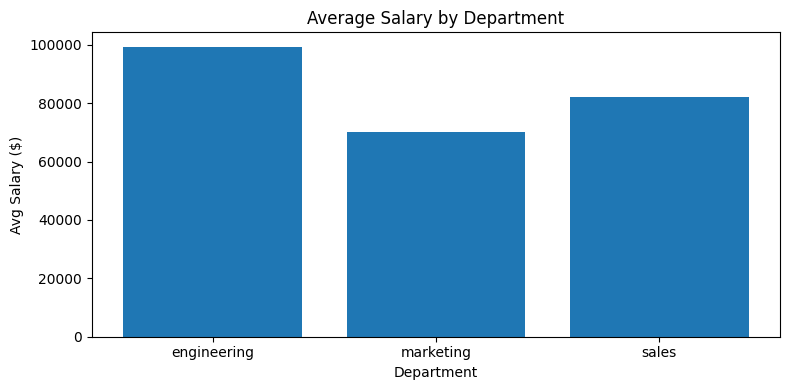

In [8]:
import matplotlib.pyplot as plt

pandas_df = dept_stats.toPandas()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(pandas_df["department"], pandas_df["avg_salary"])
ax.set_title("Average Salary by Department")
ax.set_ylabel("Avg Salary ($)")
ax.set_xlabel("Department")
plt.tight_layout()
plt.show()

In [9]:
spark.stop()
print("Session closed.")

Session closed.
